QSI1D MRA layer

---

Kishore Kumar Tarafdar, 1Jul2025

In [1]:
pwd

'/data1/kishoretarafdar/src.port/multiresolution_kernels.v0/VolterraSys/nonlinear_kernels'

        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    

        Select a GPU with a memory limit

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id=1, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from TFDWT.DWT1DFB import DWT1D, IDWT1D
# from TFDWT.DWT2DFB import DWT2D, IDWT2D


2025-07-02 22:19:10.815211: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751474950.835581  214885 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751474950.841908  214885 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 22:19:10.863088: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


I0000 00:00:1751474953.085757  214885 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:23:00.0, compute capability: 8.6


In [2]:
import matplotlib.pyplot as plt

In [3]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
# x = tf.constant([1.,2], dtype=tf.float32)

In [4]:
# h = tf.constant([1,2], dtype=tf.float32)

        new QSI mra 1D layer

In [6]:
import tensorflow as tf
from TFDWT.DWT1DFB import DWT1D, IDWT1D
from TFDWT.DWT2DFB import DWT2D, IDWT2D

@tf.keras.utils.register_keras_serializable()
class QSIVolterra1Dmra(tf.keras.layers.Layer):
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters
        self.wave = wave
        # self.dwt2 = DWT2D(self.wave, clean=False)
        # self.idwt1 = IDWT1D(self.wave, clean=False)

    def build(self, input_shape):
        self.N = input_shape[1]         # sequence length
        self.channels = input_shape[-1] # number of channels
        # Multi-channel kernel: (L, channels)
        kernel_shape = (self.L, self.channels, self.filters)
        self.h = self.add_weight(
            # shape=(self.L, self.channels),
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='UIR_kernel')
        super().build(input_shape)
    
    def make_mra_h2(self):
        # Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
        h2 = tf.einsum('ico,jco->ijco', self.h, self.h)  # (L, L, channels)
        self.h2 = h2
        # Pad to (N, N, channels)
        paddings = [
            [0, self.N - self.L],
            [0, self.N - self.L],
            [0, 0],
            [0, 0]
        ]
        h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
        # self.h2_padded = h2_padded
        ## creating h[n-k1,n-k2]
        # N = Npoint
        n = tf.range(self.N)
        # Create circular indices for all possible shifts
        # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
        row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        h2_rows_shifted = tf.gather(h2_padded, row_indices, axis=0)         # [N, N, N]
        h2_columns_shifted = tf.gather(h2_rows_shifted, row_indices,   # [N, N, N]
                                        axis=2, batch_dims=1)
        h2_shifted = h2_columns_shifted
        # print('h2shifted', self.h2_shifted.shape)

        def make_mra_kernel(h_shifted):
            shape = tf.shape(h_shifted)
            _ = tf.reshape(h_shifted, [shape[0], shape[1], shape[2], shape[3] * shape[4]])
            _ = DWT2D(self.wave, clean=False)(_)
            h_init = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4]])
            # print(h_init.shape, tf.squeeze(h_init))

            # dwt of third axis
            shape = tf.shape(h_init)
            shape
            _ = tf.reshape(h_init, [shape[0], shape[1], shape[2]*shape[3]*shape[4]])
            _ = tf.transpose(_, perm=[1,0,2])
            _ = DWT1D(self.wave, clean=False)(_)
            _ = tf.transpose(_, perm=[1,0,2])
            H = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4]])
            return H
        H = make_mra_kernel(h2_shifted)
        print('H',H.shape)
        return H


        # ## update this for batched multichannel
        # _ = tf.expand_dims(tf.cast(h2_shifted, dtype=tf.float32), axis=-1)
        # h_init = DWT2D(self.wave, clean=False)(_)
        # print(tf.squeeze(h_init))

        # H = tf.expand_dims(
        #     tf.transpose(
        #         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
        #         perm=[1,0,2]),axis=-1)
        # H[:,:,:,0]



        


    def call(self, x):
        # x: (batch, N, channels)
        x2 = tf.einsum('bic,bjc->bijc', x, x)  # (batch, N, N, channels)
        print('x2', x2.shape)
        α2 = DWT2D(self.wave, clean=False)(x2)
        print('α2', α2.shape)
        H = self.make_mra_h2()
        ## Fitlering
        β = tf.einsum('ijkco,bjkc->bio', H, α2)
        print('β', β.shape)

        # print(x2.shape, self.h2_shifted.shape)
        # y = tf.einsum('ijkco, bjkc->bio', self.h2_shifted, x2)
        # y2 = self.idwt1(β)
        y2 = IDWT1D(self.wave, clean=False)(β)
        print('y2', y2.shape)
        return y2
        
        

    def get_filter(self):
        return self.h2

        
if __name__ =='__main__':

    # Define input shape and build the model for summary
    N = 128
    input_shape = (N, 1)  # Replace N with the actual size of x
    inputs = tf.keras.Input(shape=input_shape)

    # Create an instance of the custom layer
    # h2 = np.array([[1, 2], 
    #           [1, 3]]).astype(np.float32)
    # H = TraceConv1Dio(kernel=tf.expand_dims(h2, axis=-1))
    # (tf.expand_dims(tf.expand_dims(x2,axis=0),axis=-1))

    #conv1d_filters=32, conv1d_kernel_size=3, 
    #  conv2d_filters=32, conv2d_kernel_size=3)

    # Apply the custom layer to the inputs
    H = QSIVolterra1Dmra()
    outputs = H(inputs)

    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Print the model summary
    model.summary()


x2 (None, 128, 128, 1)
(64, 128) (64, 128) H0, H1
(128, 128) (None, 128, 128, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 128, 128, 1) +
α2 (None, 128, 128, 1)
(64, 128) (64, 128) H0, H1
(128, 128) (128, 128, 128, 1) <dtype: 'float32'> <dtype: 'float32'>
(128, 128, 128, 1) +
H (128, 128, 128, 1, 1)
β (None, 128, 1)
y2 (None, 128, 1)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra1_dmra_3            │ (None, 128, 1)         │             4 │
│ (QSIVolterra1Dmra)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

        Fit a sample model

In [7]:
# Functional model
N, channels, filters = 8, 1, 1
input_shape = (N, channels)  # Replace N with the actual size of x            #1D
# input_shape = (N, N, channels)  # Replace N with the actual size of x       #2D
# input_shape = (N, N, N, channels)  # Replace N with the actual size of x    #3D
inputs = tf.keras.Input(shape=input_shape)

# Apply the custom layer to the inputs
H = QSIVolterra1Dmra(filters=filters)
outputs = H(inputs)

# Build the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse', jit_compile=False)
model.summary()

# Random data
## 1D
inputs_data = tf.random.normal((1, N, 1))
targets = tf.random.normal((1, N, 1))
## 2D
# inputs_data = tf.random.normal((1, N, N, 1))
# targets = tf.random.normal((1, N, N, 1))
## 3D
# inputs_data = tf.random.normal((1, N, N, N, 1))
# targets = tf.random.normal((1, N, N, N, 1))


# Training loop for 5 epochs
epochs=5
# for epoch in range(5):
history = model.fit(inputs_data, targets, epochs=5, verbose=1)

x2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (None, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 8, 8, 1) +
α2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (8, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(8, 8, 8, 1) +
H (8, 8, 8, 1, 1)
β (None, 8, 1)
y2 (None, 8, 1)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra1_dmra_4            │ (None, 8, 1)           │             4 │
│ (QSIVolterra1Dmra)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
x2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (None, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 8, 8, 1) +
α2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (8, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(8, 8, 8, 1) +
H (8, 8, 8, 1, 1)
β (None, 8, 1)
y2 (None, 8, 1)
x2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (None, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 8, 8, 1) +
α2 (None, 8, 8, 1)
(4, 8) (4, 8) H0, H1
(8, 8) (8, 8, 8, 1) <dtype: 'float32'> <dtype: 'float32'>
(8, 8, 8, 1) +
H (8, 8, 8, 1, 1)
β (None, 8, 1)
y2 (None, 8, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 29.9893
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 29.8142
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 29.6400
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 29.4666
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 29.2942


In [6]:
# Generate a random multi-channel input
import numpy as np
np.random.seed(42)
batch_size, N, channels, filters = 1, N, 1, 1
x_np = np.random.randn(batch_size, N, channels).astype(np.float32)
x = tf.constant(x_np)
x.shape, x.dtype
# Instantiate the layer
# H = QSIVolterra1D(filters=filters)

# Call the layer
# ylay = H(x)

# print("Input shape:", x.shape)
# print("Output shape:", ylay.shape)
# print("Output (first batch example):\n", ylay[0].numpy())

(TensorShape([1, 128, 1]), tf.float32)

In [7]:
# ylay = H(tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0))
ylay = H(x)
ylay = tf.squeeze(ylay).numpy()
ylay

x2 (1, 128, 128, 1)
α2 (1, 128, 128, 1)
β (1, 128, 1)
y2 (1, 128, 1)


array([ 6.97904408e-01,  5.59136868e-02,  7.67707825e-05,  9.48376656e-01,
        7.84117430e-02,  1.28485262e-04,  1.21389973e+00,  4.80085164e-01,
        1.03017241e-02,  3.65417302e-01,  6.76154196e-02,  2.54570216e-01,
        2.79201567e-02,  6.98386908e-01,  2.00602126e+00,  3.28924894e-01,
        1.38079846e+00,  5.69768906e-01,  1.84903443e-01,  1.42292643e+00,
        9.83978808e-02,  5.12665510e-03,  3.44200909e-01,  5.79580665e-04,
        5.09719849e-01,  1.58262253e-03,  8.18928301e-01,  1.45593107e-01,
        2.45019794e-03,  5.01514673e-01,  2.93133818e-02,  1.30610377e-01,
        2.06986710e-01,  4.92936850e-01,  4.46222603e-01,  4.49527949e-02,
        4.53886896e-01,  1.48806840e-01,  2.35809016e+00,  2.74486542e-02,
        8.23444277e-02,  3.55011076e-02,  2.13513244e-03,  9.77826025e-03,
        3.74082446e-01,  5.59267163e-01,  1.98595554e-01,  4.25518379e-02,
        4.38997149e-02,  6.40166998e-01,  7.16443639e-04,  1.56667996e-02,
        1.02198100e+00,  

In [8]:
h2 = tf.squeeze(H.get_filter())
h2

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[ 0.15820359,  0.11617792, -0.01432928,  0.13937554],
       [ 0.11617792,  0.08531608, -0.0105228 ,  0.10235141],
       [-0.01432928, -0.0105228 ,  0.00129787, -0.01262393],
       [ 0.13937554,  0.10235141, -0.01262393,  0.12278824]],
      dtype=float32)>

In [9]:
x.shape

TensorShape([1, 128, 1])

In [10]:
# x = x[0,:,0]

In [11]:
x = tf.squeeze(x)

h_padded tf.Tensor(
[[ 0.15820359  0.11617792 -0.01432928 ...  0.          0.
   0.        ]
 [ 0.11617792  0.08531608 -0.0105228  ...  0.          0.
   0.        ]
 [-0.01432928 -0.0105228   0.00129787 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]], shape=(128, 128), dtype=float32)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 1

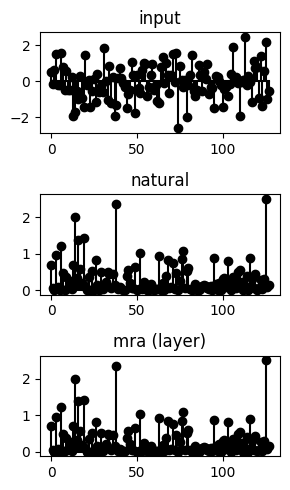

In [12]:


L = h2.shape[0] #filter length
# n = tf.range(L) 
Npoint = x.shape[0]
# Npoint = len(x)
paddings = [
        [0, Npoint - L],  # Depth dimension
        [0, Npoint - L]
        #    0,
        #    0,
        ]
# x
Npoint, paddings
h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
print('h_padded', h_padded)
h_padded.shape



x2 = tf.einsum('i,j->ij',x,x)
x2

### NAtural domain (alternative)
# q2 = tf.einsum('ijk,jk->i', h_columns_shifted, x2) ## faster
# slower version 
import numpy as np
def compute_q2(x2, h2):
    N = x2.shape[0]
    q2 = np.zeros(N).astype(float)
    for n in range(N):
        q2[n] = np.sum(h2 * x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)])
        print(x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)].shape)
    return q2

q2 = compute_q2(x2.numpy(),h_padded.numpy())
q2

plt.figure(figsize=(3,5))
plt.subplot(3,1,1), plt.stem(tf.squeeze(x).numpy(),'k', basefmt="k"), plt.title(f'input')
plt.subplot(3,1,2), plt.stem(tf.squeeze(q2).numpy(),'k', basefmt="k"), plt.title(f'natural')
# plt.subplot(3,1,3), plt.stem(tf.squeeze(y2).numpy(),'k', basefmt="k"), plt.title(f'Volterra (haar)')
plt.subplot(3,1,3), plt.stem(tf.squeeze(ylay).numpy(),'k', basefmt="k"), plt.title(f'mra (layer)')

plt.tight_layout()

In [13]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:

# h = tf.constant([1,2], dtype=tf.float32)

# # %% Quadratic kernel (m=2)
# #"""Quadratic kernel"""
# # x = [0,0,0,1,0,0,0,0]
# # filter init
# # h = tf.constant([1, 2, 1])
# h2 = tf.einsum('i,j->ij', h, h)
# print(h2)
# L = h.shape[0] #filter length
# # n = tf.range(L) 
# Npoint = x.shape[0]
# # Npoint = len(x)
# paddings = [
#         [0, Npoint - L],  # Depth dimension
#         [0, Npoint - L]
#         #    0,
#         #    0,
#         ]
# # x
# Npoint, paddings
# h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
# print('h_padded', h_padded)
# h_padded.shape

# ## creating h[n-k1,n-k2]
# N = Npoint
# n = tf.range(N)
# # Create circular indices for all possible shifts
# # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
# row_indices = tf.math.mod(n[:, tf.newaxis] - n, N)
# rows_shifted = tf.gather(h_padded, row_indices, axis=0)         # [N, N, N]
# rows_shifted
# h_columns_shifted = tf.gather(rows_shifted, row_indices,   # [N, N, N]
#                                 axis=2, batch_dims=1)
# h_columns_shifted, h_columns_shifted.shape




# _ = tf.expand_dims(tf.cast(h_columns_shifted, dtype=tf.float32), axis=-1)
# h_init = DWT2D(wave, clean=False)(_)
# print(tf.squeeze(h_init))

# H = tf.expand_dims(
#     tf.transpose(
#         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
#         perm=[1,0,2]),axis=-1)
# H[:,:,:,0]







# x2 = tf.einsum('i,j->ij',x,x)
# x2

# α2 = DWT2D(wave, clean=False)(tf.expand_dims(tf.expand_dims(x2, axis=-1),axis=0))
# α2.shape, tf.squeeze(α2)


# beta = tf.expand_dims(
#     tf.expand_dims(
#         tf.stack(
#             [tf.reduce_sum(H[k:k+1,:,:,:] * α2) for k in range(H.shape[0])]
#             ), axis=-1),axis=0)
# beta

# y2 = IDWT1D(wave, clean=False)(beta)
# y2



In [ ]:
# h = tf.constant([1,2], dtype=tf.float32)

# # %% Quadratic kernel (m=2)
# #"""Quadratic kernel"""
# # x = [0,0,0,1,0,0,0,0]
# # filter init
# # h = tf.constant([1, 2, 1])
# h2 = tf.einsum('i,j->ij', h, h)
# print(h2)

In [2]:
import tensorflow as tf
from TFDWT.DWT1DFB import DWT1D, IDWT1D
from TFDWT.DWT2DFB import DWT2D, IDWT2D

@tf.keras.utils.register_keras_serializable()
class QSIVolterra1Dmra(tf.keras.layers.Layer):
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters
        self.wave = wave
        self.dwt2 = DWT2D(self.wave, clean=False)
        self.idwt1 = IDWT1D(self.wave, clean=False)

    def build(self, input_shape):
        self.N = input_shape[1]         # sequence length
        self.channels = input_shape[-1] # number of channels
        # Multi-channel kernel: (L, channels)
        kernel_shape = (self.L, self.channels, self.filters)
        h = self.add_weight(
            # shape=(self.L, self.channels),
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='UIR_kernel'
        )
        
        # Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
        h2 = tf.einsum('ico,jco->ijco', h, h)  # (L, L, channels)
        self.h2 = h2
        # Pad to (N, N, channels)
        paddings = [
            [0, self.N - self.L],
            [0, self.N - self.L],
            [0, 0],
            [0, 0]
        ]
        h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
        # self.h2_padded = h2_padded
        ## creating h[n-k1,n-k2]
        # N = Npoint
        n = tf.range(self.N)
        # Create circular indices for all possible shifts
        # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
        row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        h2_rows_shifted = tf.gather(h2_padded, row_indices, axis=0)         # [N, N, N]
        h2_columns_shifted = tf.gather(h2_rows_shifted, row_indices,   # [N, N, N]
                                        axis=2, batch_dims=1)
        h2_shifted = h2_columns_shifted
        # print('h2shifted', self.h2_shifted.shape)

        def make_mra_kernel(h_shifted):
            shape = tf.shape(h_shifted)
            _ = tf.reshape(h_shifted, [shape[0], shape[1], shape[2], shape[3] * shape[4]])
            _ = DWT2D(self.wave, clean=False)(_)
            h_init = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4]])
            # print(h_init.shape, tf.squeeze(h_init))

            # dwt of third axis
            shape = tf.shape(h_init)
            shape
            _ = tf.reshape(h_init, [shape[0], shape[1], shape[2]*shape[3]*shape[4]])
            _ = tf.transpose(_, perm=[1,0,2])
            _ = DWT1D(self.wave, clean=False)(_)
            _ = tf.transpose(_, perm=[1,0,2])
            H = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4]])
            return H
        self.H = make_mra_kernel(h2_shifted)
        print('H',self.H.shape)
        super().build(input_shape)



        # ## update this for batched multichannel
        # _ = tf.expand_dims(tf.cast(h2_shifted, dtype=tf.float32), axis=-1)
        # h_init = DWT2D(self.wave, clean=False)(_)
        # print(tf.squeeze(h_init))

        # H = tf.expand_dims(
        #     tf.transpose(
        #         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
        #         perm=[1,0,2]),axis=-1)
        # H[:,:,:,0]



        


    def call(self, x):
        # x: (batch, N, channels)
        x2 = tf.einsum('bic,bjc->bijc', x, x)  # (batch, N, N, channels)
        print('x2', x2.shape)
        α2 = self.dwt2(x2)
        # α2 = DWT2D(self.wave, clean=False)(x2)
        print('α2', α2.shape)
        ## Fitlering
        β = tf.einsum('ijkco,bjkc->bio', self.H, α2)
        print('β', β.shape)

        # print(x2.shape, self.h2_shifted.shape)
        # y = tf.einsum('ijkco, bjkc->bio', self.h2_shifted, x2)
        y2 = self.idwt1(β)
        # y2 = IDWT1D(self.wave, clean=False)(β)
        print('y2', y2.shape)
        return y2
        
        

    def get_filter(self):
        return self.h2

        
if __name__ =='__main__':

    # Define input shape and build the model for summary
    N = 128
    input_shape = (N, 1)  # Replace N with the actual size of x
    inputs = tf.keras.Input(shape=input_shape)

    # Create an instance of the custom layer
    # h2 = np.array([[1, 2], 
    #           [1, 3]]).astype(np.float32)
    # H = TraceConv1Dio(kernel=tf.expand_dims(h2, axis=-1))
    # (tf.expand_dims(tf.expand_dims(x2,axis=0),axis=-1))

    #conv1d_filters=32, conv1d_kernel_size=3, 
    #  conv2d_filters=32, conv2d_kernel_size=3)

    # Apply the custom layer to the inputs
    H = QSIVolterra1Dmra()
    outputs = H(inputs)

    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Print the model summary
    model.summary()


2025-07-01 05:35:39.847276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751328339.869617 3575610 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751328339.876457 3575610 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-01 05:35:39.900057: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-01 05:35:41.783830: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL

(64, 128) (64, 128) H0, H1
(128, 128) (128, 128, 128, 1) <dtype: 'float32'> <dtype: 'float32'>
(128, 128, 128, 1) +
H (128, 128, 128, 1, 1)
x2 (None, 128, 128, 1)
(64, 128) (64, 128) H0, H1
(128, 128) (None, 128, 128, 1) <dtype: 'float32'> <dtype: 'float32'>
(None, 128, 128, 1) +
α2 (None, 128, 128, 1)
β (None, 128, 1)
y2 (None, 128, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra1_dmra              │ (None, 128, 1)         │             4 │
│ (QSIVolterra1Dmra)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Generate a random multi-channel input
import numpy as np
np.random.seed(42)
batch_size, N, channels, filters = 1, N, 1, 1
x_np = np.random.randn(batch_size, N, channels).astype(np.float32)
x = tf.constant(x_np)
x.shape, x.dtype
# ylay = H(tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0))
ylay = H(x)
ylay = tf.squeeze(ylay).numpy()
ylay


x2 (1, 128, 128, 1)
(128, 128) (1, 128, 128, 1) <dtype: 'float32'> <dtype: 'float32'>


TypeError: Exception encountered when calling DWT2D.call().

[1m<tf.Tensor 'dwt2d/concat_2:0' shape=(128, 128) dtype=float32> is out of scope and cannot be used here. Use return values, explicit Python locals or TensorFlow collections to access it.
Please see https://www.tensorflow.org/guide/function#all_outputs_of_a_tffunction_must_be_return_values for more information.

<tf.Tensor 'dwt2d/concat_2:0' shape=(128, 128) dtype=float32> was defined here:
    File "<frozen runpy>", line 198, in _run_module_as_main
    File "<frozen runpy>", line 88, in _run_code
    File "/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    File "/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    File "/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    File "/data1/kishoretarafd